# Iterative Temporal Parent Discovery

Dev | Jacqueline Maasch | August 2026

In [1]:
# General imports.
import pandas as pd
import numpy as np
#import pickle
import matplotlib.pyplot as plt
import time
from string import ascii_uppercase as alphabet

# Time series causal discovery.
import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI # also for PCMCI+
from tigramite.independence_tests.gsquared import Gsquared # univariate discrete/categorical vars
from tigramite.independence_tests.cmisymb import CMIsymb # multivariate discrete/categorical vars (permutation-based)
from tigramite.independence_tests.parcorr import ParCorr # univariate, continuous variables with linear dependencies and Gaussian noise

# VLCD.
from vlcd import PCMCIConfig, pcmci

# Vanilla causal discovery.
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.utils.cit import CIT

# Custom discovery algorithms.
from padl import PaDL
from itpd import ITPD, Utils

# Metrics.
#from dodiscover.metrics import structure_hamming_dist as SHD
from cdt.metrics import precision_recall
from cdt.metrics import SHD
from cdt.metrics import SID

# Graphical modeling.
import networkx as nx

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


# ITPD

## Generate random time series

In [2]:
# Get random data.
u = Utils()
dfs = []
graphs = []
adj_matrices = []
p2c_list = []
c2p_list = []
M = 1_000
T = 7
N = 10
max_children = 2
plot = False
iters = 10 # total random datasets to generate.

for i in range(iters):
    df, p2c, c2p, G, true_adj = u.get_data(M = M, 
                                           T = T,
                                           N = N, 
                                           max_children = max_children,
                                           plot = plot)
    dfs.append(df)
    graphs.append(G)
    adj_matrices.append(true_adj)
    p2c_list.append(p2c)
    c2p_list.append(c2p)

In [3]:
dfs[0]

,A0,A1,A2,A3,A4,A5,A6,B0,B1,B2,...,I4,I5,I6,J0,J1,J2,J3,J4,J5,J6
0,0.158700,-0.470367,1.103909,-1.125729,0.285872,1.118605,-3.744772,1.652920,2.186642,-3.325629,...,1.910732,0.255044,0.254808,1.673256,1.215292,-0.364499,2.420331,-4.300083,14.326965,-5.942129
1,-0.994005,2.176456,-3.957471,-2.697423,-1.253532,-0.535598,1.794834,0.405109,-1.134031,2.040233,...,1.668833,0.750756,1.218661,0.753296,1.270799,1.281648,2.336803,-2.405493,0.141183,-2.342654
2,0.302215,0.959606,-2.761929,-3.151189,-3.096303,-4.139319,7.298790,-0.992659,0.459306,-2.472546,...,16.317620,11.657088,9.404329,0.172115,0.222450,-0.508321,0.284084,0.974490,-9.228886,7.095309
3,-0.362906,1.542740,-1.715225,-1.327600,-1.520355,-3.909219,6.310511,-0.538595,-0.284806,1.208907,...,-2.936072,-7.090714,-5.538419,-0.245209,0.536939,1.032398,3.551796,-3.347638,4.634259,-2.872496
4,0.162318,-1.019840,1.447015,1.632338,0.152338,1.623801,-1.141080,1.023030,0.652868,-2.501396,...,1.387811,-0.417931,-0.065306,0.937050,2.558691,2.662911,5.052636,-3.733306,9.604434,-1.422440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.424489,1.656599,-2.722625,0.166697,-0.923417,-1.772271,1.955176,0.697384,-1.316126,1.250105,...,-1.561296,2.095394,4.204014,0.871829,1.253128,1.483829,2.325265,-2.015292,6.970023,-0.314027
996,-1.053550,1.085919,-1.400098,0.616999,1.436465,0.395304,-0.561301,0.257027,0.757493,-0.559870,...,-10.889853,-1.494042,-1.185803,1.775079,3.909052,3.706809,-0.252124,0.716527,7.523647,-3.159311
997,0.320123,-0.174744,-0.779480,-0.844192,-0.504663,-1.890858,1.252547,0.538750,-1.065722,1.727167,...,6.260548,3.311264,3.422674,-1.410091,-2.611572,-2.770882,-4.535403,4.387010,-15.759010,4.844365
998,-0.421180,1.999033,-4.131414,-3.667637,-2.223661,-1.754381,2.668491,0.158811,0.883566,-0.158207,...,-2.701939,-4.726040,-2.837433,1.622241,2.979581,1.980700,4.426638,-3.447315,12.289405,-5.603604


In [4]:
p2c_list[0]

{'A0': ['A1'],
 'A1': ['A2'],
 'A2': ['A3'],
 'A3': ['A4'],
 'A4': ['A5', 'C6'],
 'A5': ['A6', 'G6', 'C6'],
 'A6': [],
 'B0': ['B1'],
 'B1': ['B2'],
 'B2': ['B3', 'C3', 'G3'],
 'B3': ['B4'],
 'B4': ['B5', 'H6', 'J5'],
 'B5': ['B6'],
 'B6': [],
 'C0': ['C1', 'E1', 'D2'],
 'C1': ['C2'],
 'C2': ['C3', 'F6'],
 'C3': ['C4'],
 'C4': ['C5', 'H6'],
 'C5': ['C6', 'E6'],
 'C6': [],
 'D0': ['D1'],
 'D1': ['D2'],
 'D2': ['D3'],
 'D3': ['D4'],
 'D4': ['D5'],
 'D5': ['D6', 'H6', 'G6'],
 'D6': [],
 'E0': ['E1'],
 'E1': ['E2'],
 'E2': ['E3', 'I3'],
 'E3': ['E4', 'J5', 'H4'],
 'E4': ['E5', 'G6', 'I5'],
 'E5': ['E6', 'G6', 'C6'],
 'E6': [],
 'F0': ['F1', 'B6'],
 'F1': ['F2'],
 'F2': ['F3', 'I5'],
 'F3': ['F4'],
 'F4': ['F5', 'E6'],
 'F5': ['F6', 'D6'],
 'F6': [],
 'G0': ['G1', 'C5'],
 'G1': ['G2'],
 'G2': ['G3'],
 'G3': ['G4'],
 'G4': ['G5'],
 'G5': ['G6', 'C6', 'D6'],
 'G6': [],
 'H0': ['H1', 'H2', 'D6'],
 'H1': ['H2'],
 'H2': ['H3', 'C5', 'J3'],
 'H3': ['H4'],
 'H4': ['H5', 'F6', 'F5'],
 'H5': ['H6', 

## Oracle

In [5]:
#%%capture

#'''
test = "oracle"
alpha = 0.01
tau_max = None
pairs = None
var_names = list(alphabet[:N])

accuracies = []
auprs = []
shds = []
total_tests = []
cond_sizes = []
itpd_oracle_times = []

for i in range(iters):
    start = time.time()
    it = ITPD(dfs[i],
              var_names = var_names,
              pairs = pairs,
              independence_test = test,
              alpha = alpha,
              tau_max = tau_max,
              true_adj = adj_matrices[i])
    accuracy, aupr, shd = it.itpd_naive()
    itpd_oracle_times.append(time.time() - start)
    
    total_tests.append(np.sum(it.total_tests))
    #cond_sizes += it.conditioning_set_sizes
    
    accuracies.append(accuracy)
    auprs.append(aupr)
    shds.append(shd)

print()
print(f"Mean runtime     : {round(np.mean(itpd_oracle_times),4)} seconds")
print(f"Mean total tests : {round(np.mean(total_tests),2)}")
#print(f"Mean cond. set : {round(np.mean(cond_sizes),2)}")
print()
print(f"Mean accuracy    : {round(np.mean(accuracies)*100,2)}")
print(f"Mean AUPR        : {round(np.mean(auprs)*100,2)}")
print(f"Mean SHD         : {round(np.mean(shds),2)}")
#'''

ITPD complete in 0.653 seconds.
ITPD complete in 0.7744 seconds.
ITPD complete in 0.6204 seconds.
ITPD complete in 0.5641 seconds.
ITPD complete in 0.6584 seconds.
ITPD complete in 0.6279 seconds.
ITPD complete in 0.592 seconds.
ITPD complete in 0.7687 seconds.
ITPD complete in 0.6463 seconds.
ITPD complete in 0.5799 seconds.

Mean runtime     : 0.6494 seconds
Mean total tests : 6505.9

Mean accuracy    : 100.0
Mean AUPR        : 100.0
Mean SHD         : 0.0


## From data

In [6]:
test = "fisherz"
alpha = 0.01
tau_max = None
pairs = None
var_names = list(alphabet[:N])

accuracies = []
auprs = []
shds = []
total_tests = []
cond_sizes = []
itpd_times = []

for i in range(iters):
    start = time.time()
    it = ITPD(dfs[i],
              var_names = var_names,
              pairs = pairs,
              independence_test = test,
              alpha = alpha,
              tau_max = tau_max,
              true_adj = adj_matrices[i])
    accuracy, aupr, shd = it.itpd_naive()
    itpd_times.append(time.time() - start)
    
    total_tests.append(np.sum(it.total_tests))
    #cond_sizes += it.conditioning_set_sizes
    
    accuracies.append(accuracy)
    auprs.append(aupr)
    shds.append(shd)

print()
print(f"Mean runtime     : {round(np.mean(itpd_times),4)} seconds")
print(f"Mean total tests : {round(np.mean(total_tests),2)}")
#print(f"Mean cond. set : {round(np.mean(cond_sizes),2)}")
print()
print(f"Mean accuracy    : {round(np.mean(accuracies)*100,2)}")
print(f"Mean AUPR        : {round(np.mean(auprs)*100,2)}")
print(f"Mean SHD         : {round(np.mean(shds),2)}")

ITPD complete in 0.1606 seconds.
ITPD complete in 0.1681 seconds.
ITPD complete in 0.1537 seconds.
ITPD complete in 0.1458 seconds.
ITPD complete in 0.1481 seconds.
ITPD complete in 0.1466 seconds.
ITPD complete in 0.1496 seconds.
ITPD complete in 0.158 seconds.
ITPD complete in 0.1586 seconds.
ITPD complete in 0.1486 seconds.

Mean runtime     : 0.1549 seconds
Mean total tests : 5434.2

Mean accuracy    : 76.82
Mean AUPR        : 88.66
Mean SHD         : 27.0


In [7]:
print(f"(N*T)**2 / mean total tests: {(N*T)**2} / {round(np.mean(total_tests),2)} = {round(((N*T)**2) / np.mean(total_tests),2)}")

(N*T)**2 / mean total tests: 4900 / 5434.2 = 0.9


(array([2., 0., 1., 0., 0., 2., 3., 0., 1., 1.]),
 array([0.85729031, 0.86293406, 0.86857781, 0.87422156, 0.8798653 ,
        0.88550905, 0.8911528 , 0.89679655, 0.9024403 , 0.90808405,
        0.9137278 ]),
 <BarContainer object of 10 artists>)

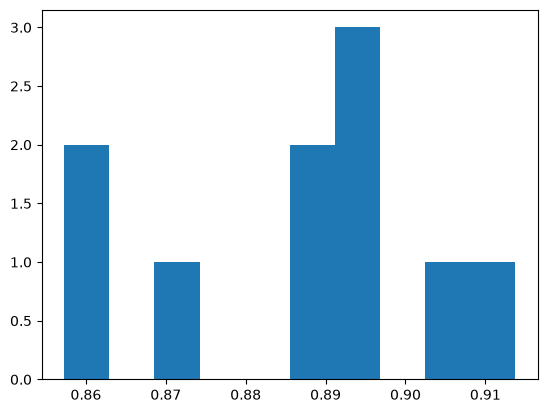

In [8]:
plt.hist(auprs)

(array([2., 0., 1., 0., 1., 2., 2., 0., 1., 1.]),
 array([0.71428571, 0.72521008, 0.73613445, 0.74705882, 0.75798319,
        0.76890756, 0.77983193, 0.7907563 , 0.80168067, 0.81260504,
        0.82352941]),
 <BarContainer object of 10 artists>)

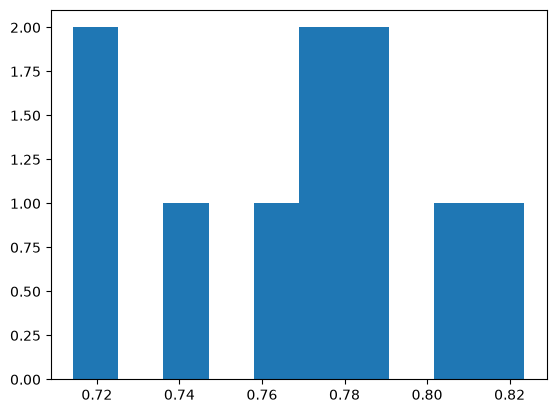

In [9]:
plt.hist(accuracies)

# PCMCI

In [10]:
%%capture
'''
# Sanity check (passed).
m_dict = u.format_tigramite(dfs[0],
                            var_names = var_names)
print(m_dict[0].shape)
print(len(m_dict.keys()))
print(M)
print(T)
print(N)
print(m_dict[1])
dfs[0]
'''

In [11]:
TAU_MIN = 1
TAU_MAX = 3

pcmci_times = []
for i in range(iters):

    m_dict = u.format_tigramite(dfs[i],
                                var_names = var_names)
    df_tigra = pp.DataFrame(m_dict, 
                            analysis_mode = "multiple", 
                            var_names = var_names)

    pcmci = PCMCI(dataframe = df_tigra, cond_ind_test = ParCorr())
    
    start = time.time()
    results = pcmci.run_pcmci(tau_min = TAU_MIN,
                              tau_max = TAU_MAX, 
                              pc_alpha = 0.01)
    pcmci_runtime = time.time()-start
    pcmci_times.append(pcmci_runtime)
    print(f"PCMCI complete in {round(pcmci_runtime,4)} seconds.")
    
    '''
    tp.plot_graph(graph=results['graph'], 
                  val_matrix=results['val_matrix'], 
                  var_names=var_names)
    plt.show()
    '''

print()
print(f"Mean runtime     : {round(np.mean(pcmci_times),4)} seconds")

PCMCI complete in 6.6747 seconds.
PCMCI complete in 7.4966 seconds.
PCMCI complete in 6.4044 seconds.
PCMCI complete in 6.188 seconds.
PCMCI complete in 5.9442 seconds.
PCMCI complete in 5.9546 seconds.
PCMCI complete in 6.4181 seconds.
PCMCI complete in 6.9154 seconds.
PCMCI complete in 8.2637 seconds.
PCMCI complete in 6.2355 seconds.

Mean runtime     : 6.6495 seconds


In [12]:
print(f"pcmci mean time / itpd mean time = {round(np.mean(pcmci_times) / np.mean(itpd_times),4)}")

pcmci mean time / itpd mean time = 42.9248


# End of document